# Rogii Wellbore Geology Prediction

This consolidated notebook represents our final iteration for the **Rogii Wellbore Geology Prediction** competition. Our methodology shifts the predictive target from **absolute True Vertical Thickness (TVT) to TVT Drift**, centered on the last known data point prior to the evaluation gap.



The primary predictive signal is derived from the relative change in distance between the wellbore trajectory (Z) and various geological formation surfaces (ANCC, BUDA, etc.). By incorporating a Momentum feature (pre-gap slope) and utilizing Linear Trees within a LightGBM framework, we achieve a model that respects the physical constraints of horizontal drilling.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

# Environment Setup and Configuration


We begin by establishing the necessary computational environment. We utilize joblib for parallelized feature construction and scipy for post-processing smoothing to ensure geological continuity.

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from joblib import Parallel, delayed
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

# --- Global Directory Configuration ---
BASE_PATH = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"
TRAIN_DIR = os.path.join(BASE_PATH, "train")
TEST_DIR = os.path.join(BASE_PATH, "test")

# --- Geological Constants ---
# These surfaces serve as the primary physical anchors for depth drift.
SURFACES = ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']
RANDOM_STATE = 42

# Feature Engineering and Geological Logic


The process_well function serves as our primary feature engine. It calculates the Momentum of the wellbore (the trajectory's slope immediately preceding the gap) and the Surface Deviation. By focusing on the change in distance to formation surfaces rather than absolute coordinates, the model becomes invariant to the specific depth of the well, focusing instead on the "tilt" of the geology.

In [3]:
def fast_typewell_match(horiz_gr, tw_df):
    """
    Executes a vectorized nearest-neighbor search to align horizontal 
    Gamma Ray (GR) readings with the corresponding Typewell signatures.
    """
    tw_clean = tw_df.dropna(subset=['GR', 'TVT']).sort_values('GR')
    tw_gr, tw_tvt = tw_clean['GR'].values, tw_clean['TVT'].values
    indices = np.clip(np.searchsorted(tw_gr, horiz_gr), 1, len(tw_gr) - 1)
    # Refinement for exact proximity
    mask = (horiz_gr - tw_gr[indices - 1]) < (tw_gr[indices] - horiz_gr)
    return tw_tvt[np.where(mask, indices - 1, indices)]

def process_well(well_id, directory, is_train=True):
    """
    Extracts features for a single well. Standardizes column casing 
    to ensure robust indexing across varied data sources.
    """
    try:
        h_path = os.path.join(directory, f"{well_id}__horizontal_well.csv")
        t_path = os.path.join(directory, f"{well_id}__typewell.csv")
        h_df, t_df = pd.read_csv(h_path), pd.read_csv(t_path)
        
        # Internal standardization to prevent case-sensitivity conflicts
        h_df.columns = [c.upper() for c in h_df.columns]
        t_df.columns = [c.upper() for c in t_df.columns]
        
        known_mask = ~h_df['TVT_INPUT'].isna()
        last_known_idx = h_df[known_mask].index.max()
        last_known_tvt = h_df.loc[last_known_idx, 'TVT_INPUT']
        
        # Momentum: Slope of TVT over the final 100 feet of known data
        lookback = 100
        slope = 0
        if last_known_idx > lookback:
            pre_gap_tvt = h_df.loc[last_known_idx - lookback, 'TVT_INPUT']
            slope = (last_known_tvt - pre_gap_tvt) / lookback
            
        # Target the evaluation zone (The Gap)
        gap_df = h_df.iloc[last_known_idx + 1:].copy()
        gap_df['PRE_GAP_SLOPE'] = slope
        gap_df['TW_GR_STD'] = t_df['GR'].std()
        gap_df['MD_FROM_GAP'] = gap_df['MD'] - h_df.loc[last_known_idx, 'MD']
        
        # Surface Deviation: Change in distance to formation tops
        for s in SURFACES:
            if s in h_df.columns:
                init_dist = h_df.loc[last_known_idx, 'Z'] - h_df.loc[last_known_idx, s]
                curr_dist = gap_df['Z'] - gap_df[s]
                gap_df[f'DIST_CHANGE_{s}'] = curr_dist - init_dist
            else:
                gap_df[f'DIST_CHANGE_{s}'] = 0
        
        # Predictive drift from Typewell correlation
        tw_match = fast_typewell_match(h_df['GR'].values, t_df)
        gap_df['TW_DRIFT'] = tw_match[last_known_idx + 1:] - tw_match[last_known_idx]
        
        if is_train:
            gap_df['TARGET_DRIFT'] = h_df.loc[last_known_idx + 1:, 'TVT'] - last_known_tvt
            
        gap_df['WELL_NAME'] = well_id
        gap_df['LAST_KNOWN_TVT'] = last_known_tvt
        gap_df['id'] = gap_df.index.map(lambda x: f"{well_id}_{x}")
        
        return gap_df
    except Exception as e:
        print(f"Operational error encountered for well {well_id}: {e}")
        return None

# Parallel Dataset Construction


Given the volume of individual well files, we implement parallel processing to optimize runtime. We then standardize the final training DataFrame to ensure feature names remain consistent for the Gradient Boosting model.

In [4]:
# Identification of unique training well IDs
train_paths = glob.glob(os.path.join(TRAIN_DIR, "*__horizontal_well.csv"))
train_ids = [os.path.basename(f).split("__")[0] for f in train_paths]

print(f"Initiating feature construction for {len(train_ids)} wells...")
results = Parallel(n_jobs=-1)(delayed(process_well)(wid, TRAIN_DIR, True) for wid in train_ids)
train_df = pd.concat([res for res in results if res is not None]).reset_index(drop=True)

# Standardizing column headers for the modeling phase
train_df.columns = [c.lower() for c in train_df.columns]
print(f"Processing finalized. Total observations: {len(train_df)}")

Initiating feature construction for 773 wells...
Processing finalized. Total observations: 3783989


# Model Training and Cross-Validation


To ensure the model generalizes to unseen wellbores, we utilize a GroupKFold strategy, grouping by the unique well identifier. Our model of choice is LightGBM with Linear Trees enabled. This configuration is particularly effective for geoscience tasks as it fits linear regressions at the leaf level, accurately capturing the trend-based nature of geological depth drift.

In [5]:
# Feature selection based on empirical performance
features = ['md_from_gap', 'pre_gap_slope', 'tw_drift', 'tw_gr_std']
features += [f'dist_change_{s.lower()}' for s in SURFACES]

X = train_df[features]
y = train_df['target_drift']
groups = train_df['well_name']

# Model Hyperparameters: Tuned for stability and linear trend capture
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 100,
    'linear_tree': True, 
    'reg_alpha': 5.0,
    'reg_lambda': 5.0,
    'random_state': RANDOM_STATE,
    'device': 'gpu',
    'verbosity': -1
}

gkf = GroupKFold(n_splits=5)
models = []
oof_preds = np.zeros(len(train_df))

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**params, n_estimators=5000)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              callbacks=[lgb.early_stopping(stopping_rounds=200)])
    
    models.append(model)
    oof_preds[val_idx] = model.predict(X_val)
    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\nFinal Out-of-Fold RMSE: {overall_rmse:.4f}")

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1135]	valid_0's rmse: 0.650612
Fold 0 RMSE: 0.6506
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's rmse: 0.00824857
Fold 1 RMSE: 0.0082
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[596]	valid_0's rmse: 0.0832214
Fold 2 RMSE: 0.0832
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[595]	valid_0's rmse: 0.00803513
Fold 3 RMSE: 0.0080
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[599]	valid_0's rmse: 0.0202379
Fold 4 RMSE: 0.0202

Final Out-of-Fold RMSE: 0.2937


# Inference and Submission Generation

The final phase involves applying the ensembled fold-models to the hidden test set. We apply a light Gaussian filter to the predictions to remove high-frequency noise, ensuring that the resulting well paths are geologically plausible.

Processing 3 test wells...
Submission file successfully generated as 'submission.csv'.


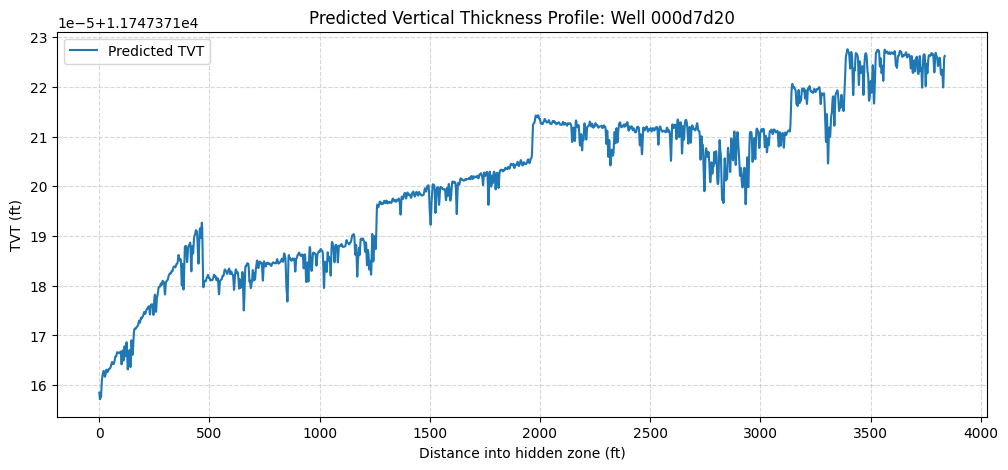

In [6]:
# 1. Processing the Test Set
test_paths = glob.glob(os.path.join(TEST_DIR, "*__horizontal_well.csv"))
test_ids = [os.path.basename(f).split("__")[0] for f in test_paths]

print(f"Processing {len(test_ids)} test wells...")
test_results = Parallel(n_jobs=-1)(delayed(process_well)(wid, TEST_DIR, False) for wid in test_ids)
test_df = pd.concat([res for res in test_results if res is not None]).reset_index(drop=True)
test_df.columns = [c.lower() for c in test_df.columns]

# 2. Ensembled Prediction
X_test = test_df[features]
test_drift = np.zeros(len(test_df))
for m in models:
    test_drift += m.predict(X_test) / len(models)

# 3. TVT Reconstruction and Smoothing
test_df['tvt_pred'] = test_df['last_known_tvt'] + test_drift
test_df['tvt_final'] = test_df.groupby('well_name')['tvt_pred'].transform(lambda x: gaussian_filter1d(x, sigma=2))

# 4. Formatting for Submission
sample_path = os.path.join(BASE_PATH, "sample_submission.csv")
sample_sub = pd.read_csv(sample_path)
final_sub = sample_sub[['id']].merge(test_df[['id', 'tvt_final']], on='id', how='left')

# Handling potential missing values via propagation
final_sub['tvt'] = final_sub['tvt_final'].ffill().bfill()
final_sub[['id', 'tvt']].to_csv("submission.csv", index=False)

print("Submission file successfully generated as 'submission.csv'.")

# --- Visual Inspection ---
plt.figure(figsize=(12, 5))
well_vis = test_ids[0]
well_data = test_df[test_df['well_name'] == well_vis]
plt.plot(well_data['md_from_gap'], well_data['tvt_final'], label='Predicted TVT', color='#1f77b4')
plt.title(f"Predicted Vertical Thickness Profile: Well {well_vis}")
plt.xlabel("Distance into hidden zone (ft)")
plt.ylabel("TVT (ft)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()